# Loan Approval Ensemble Comparison

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [6]:
data = pd.read_csv(r'C:\Users\Island\OneDrive\Desktop\ML Projects\ml-practice-lab\3- loan-approval-ensemble-comparison\datasets\loan_dataset.csv')

## EDA

### First EDA

In [7]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [9]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
data.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [11]:
data.sample(6)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
599,LP002948,Male,Yes,2,Graduate,No,5780,0.0,192.0,360.0,1.0,Urban,Y
76,LP001256,Male,No,0,Graduate,No,3750,4750.0,176.0,360.0,1.0,Urban,N
217,LP001726,Male,Yes,0,Graduate,No,3727,1775.0,131.0,360.0,1.0,Semiurban,Y
149,LP001520,Male,Yes,0,Graduate,No,4860,830.0,125.0,360.0,1.0,Semiurban,Y
544,LP002757,Female,Yes,0,Not Graduate,No,3017,663.0,102.0,360.0,NaN,Semiurban,Y
193,LP001658,Male,No,0,Graduate,No,3858,0.0,76.0,360.0,1.0,Semiurban,Y


### Features EDA

In [12]:
test_df = data.copy()

In [13]:
test_df = test_df.fillna('Unknown')
# to verify if the missing data is missing at random (MAR)
test_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#### Gender

In [14]:
test_df.groupby('Gender').Loan_ID.count()

Gender
Female     112
Male       489
Unknown     13
Name: Loan_ID, dtype: int64

In [15]:
pd.crosstab(test_df.Gender, test_df.Loan_Status)

Loan_Status,N,Y
Gender,,
Female,37,75
Male,150,339
Unknown,5,8


In [16]:
pd.crosstab(test_df.Gender, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Gender,,
Female,0.330357,0.669643
Male,0.306748,0.693252
Unknown,0.384615,0.615385


#### 

#### Maried

In [17]:
test_df.Married.value_counts()

Married
Yes        398
No         213
Unknown      3
Name: count, dtype: int64

In [18]:
pd.crosstab(test_df.Married, test_df.Loan_Status)

Loan_Status,N,Y
Married,,
No,79,134
Unknown,0,3
Yes,113,285


In [19]:
pd.crosstab(test_df.Married, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Married,,
No,0.370892,0.629108
Unknown,0.000000,1.000000
Yes,0.283920,0.716080


#### Dependents

In [20]:
test_df.Dependents.value_counts()

Dependents
0          345
1          102
2          101
3+          51
Unknown     15
Name: count, dtype: int64

In [21]:
pd.crosstab(test_df.Dependents, test_df.Loan_Status)

Loan_Status,N,Y
Dependents,,
0,107,238
1,36,66
2,25,76
3+,18,33
Unknown,6,9


In [22]:
pd.crosstab(test_df.Dependents, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Dependents,,
0,0.310145,0.689855
1,0.352941,0.647059
2,0.247525,0.752475
3+,0.352941,0.647059
Unknown,0.400000,0.600000


#### Education

In [23]:
test_df.Education.value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [24]:
pd.crosstab(test_df.Education, test_df.Loan_Status)

Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


In [25]:
pd.crosstab(test_df.Education, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Education,,
Graduate,0.291667,0.708333
Not Graduate,0.388060,0.611940


#### Self Employed

In [26]:
test_df.Self_Employed.value_counts()

Self_Employed
No         500
Yes         82
Unknown     32
Name: count, dtype: int64

In [27]:
pd.crosstab(test_df.Self_Employed, test_df.Loan_Status)

Loan_Status,N,Y
Self_Employed,,
No,157,343
Unknown,9,23
Yes,26,56


In [28]:
pd.crosstab(test_df.Self_Employed, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Self_Employed,,
No,0.314000,0.686000
Unknown,0.281250,0.718750
Yes,0.317073,0.682927


#### Applicant Income

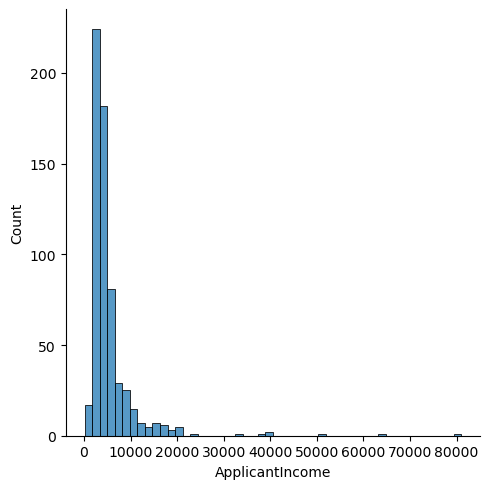

In [31]:
sns.displot(test_df, x='ApplicantIncome')

In [32]:
under_30k_df = test_df[test_df.ApplicantIncome < 30000]
above_30k_df = test_df[test_df.ApplicantIncome > 30000]

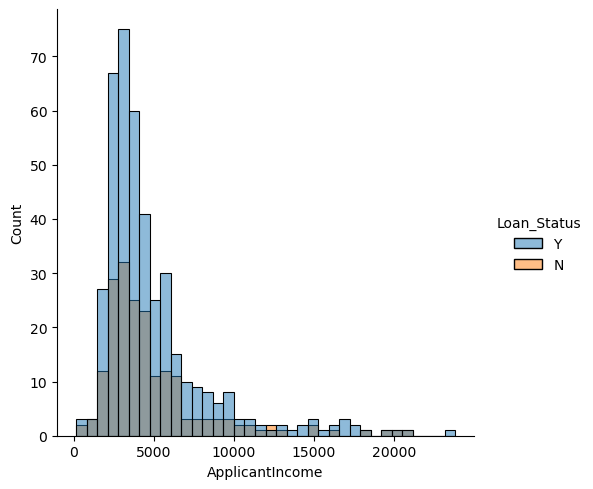

In [37]:
sns.displot(under_30k_df, x='ApplicantIncome', hue='Loan_Status')

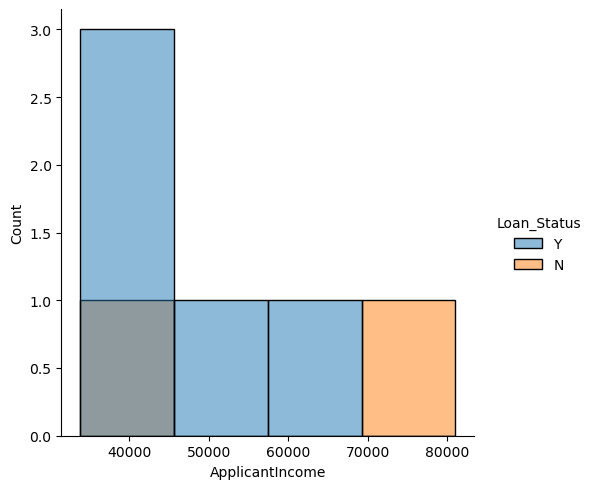

In [40]:
sns.displot(above_30k_df, x='ApplicantIncome', hue='Loan_Status')

#### Co Applicant Income

In [45]:
print(f'zero: {test_df[test_df.CoapplicantIncome == 0].shape[0]}\nnot zero: {test_df[test_df.CoapplicantIncome != 0].shape[0]}')

zero: 273
not zero: 341


In [46]:
zero_coincome_df = test_df[test_df.CoapplicantIncome == 0]
notzero_coincome_df = test_df[test_df.CoapplicantIncome != 0]

In [48]:
print(zero_coincome_df.Loan_Status.value_counts())
print(notzero_coincome_df.Loan_Status.value_counts())

Loan_Status
Y    177
N     96
Name: count, dtype: int64
Loan_Status
Y    245
N     96
Name: count, dtype: int64


In [49]:
print(zero_coincome_df.Loan_Status.value_counts(normalize=True))
print(notzero_coincome_df.Loan_Status.value_counts(normalize=True))

Loan_Status
Y    0.648352
N    0.351648
Name: proportion, dtype: float64
Loan_Status
Y    0.718475
N    0.281525
Name: proportion, dtype: float64


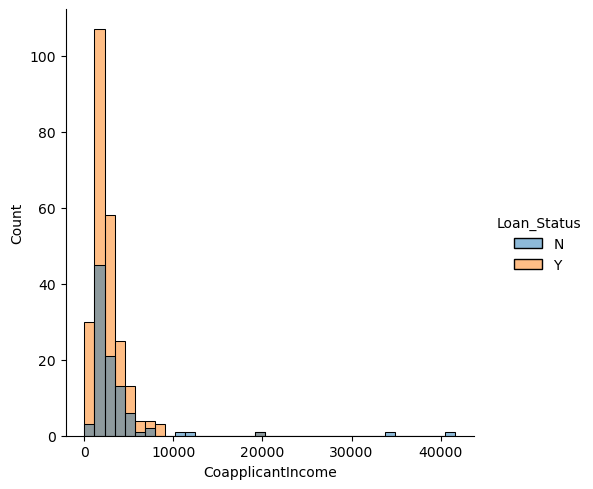

In [ ]:
sns.displot(notzero_coincome_df, x='CoapplicantIncome', hue='Loan_Status')

#### Loan Amount

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,Unknown,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


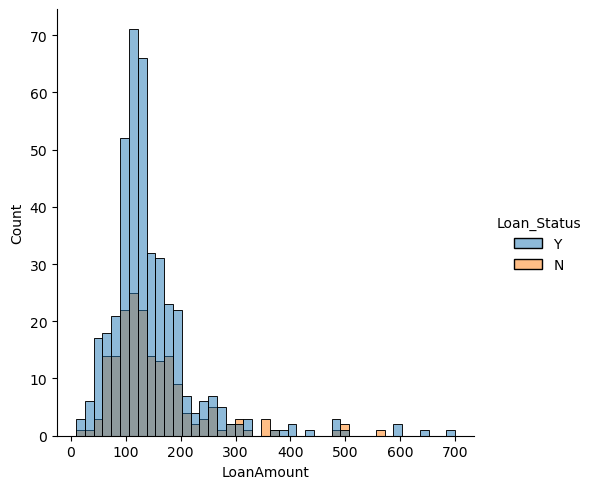

In [59]:
sns.displot(data, x='LoanAmount', hue='Loan_Status')

#### Loan Term

In [60]:
test_df.Loan_Amount_Term.value_counts()

Loan_Amount_Term
360.0      512
180.0       44
480.0       15
Unknown     14
300.0       13
240.0        4
84.0         4
120.0        3
60.0         2
36.0         2
12.0         1
Name: count, dtype: int64

In [62]:
data.groupby('Loan_Amount_Term').Loan_Status.value_counts()

Loan_Amount_Term  Loan_Status
12.0              Y                1
36.0              N                2
60.0              Y                2
84.0              Y                3
                  N                1
120.0             Y                3
180.0             Y               29
                  N               15
240.0             Y                3
                  N                1
300.0             Y                8
                  N                5
360.0             Y              359
                  N              153
480.0             N                9
                  Y                6
Name: count, dtype: int64

#### Credit History

In [67]:
test_df.Credit_History.value_counts()

Credit_History
1.0        475
0.0         89
Unknown     50
Name: count, dtype: int64

In [68]:
pd.crosstab(test_df.Credit_History, test_df.Loan_Status)

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378
Unknown,13,37


In [69]:
pd.crosstab(test_df.Credit_History, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.204211,0.795789
Unknown,0.260000,0.740000


#### Property Area

In [70]:
test_df.Property_Area.value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [71]:
pd.crosstab(test_df.Property_Area, test_df.Loan_Status)

Loan_Status,N,Y
Property_Area,,
Rural,69,110
Semiurban,54,179
Urban,69,133


In [72]:
pd.crosstab(test_df.Property_Area, test_df.Loan_Status, normalize='index')

Loan_Status,N,Y
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416
